## Sensibility test to the number of particles ##
### Using the Wasserstein metric ###

In [1]:
from scipy.stats import wasserstein_distance_nd
import xarray as xr
import shapely
import dask.array as da
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
year = 2018
month_start = 7
infol = '/scratch/project_2018610/connectivity/rasters/num_particle/'
shape_file = '/projappl/project_2018610/data/DTO4OWE_polygons/Wind_farms_Bothnian_Sea.shp'

In [2]:
gdf = gpd.read_file(shape_file)

### July 2018 ###
#### 4 farms of various size : n°1, 2, 12, 19 #### 
A grid in degree was used to calculate the histogram, instead of a grid in metres

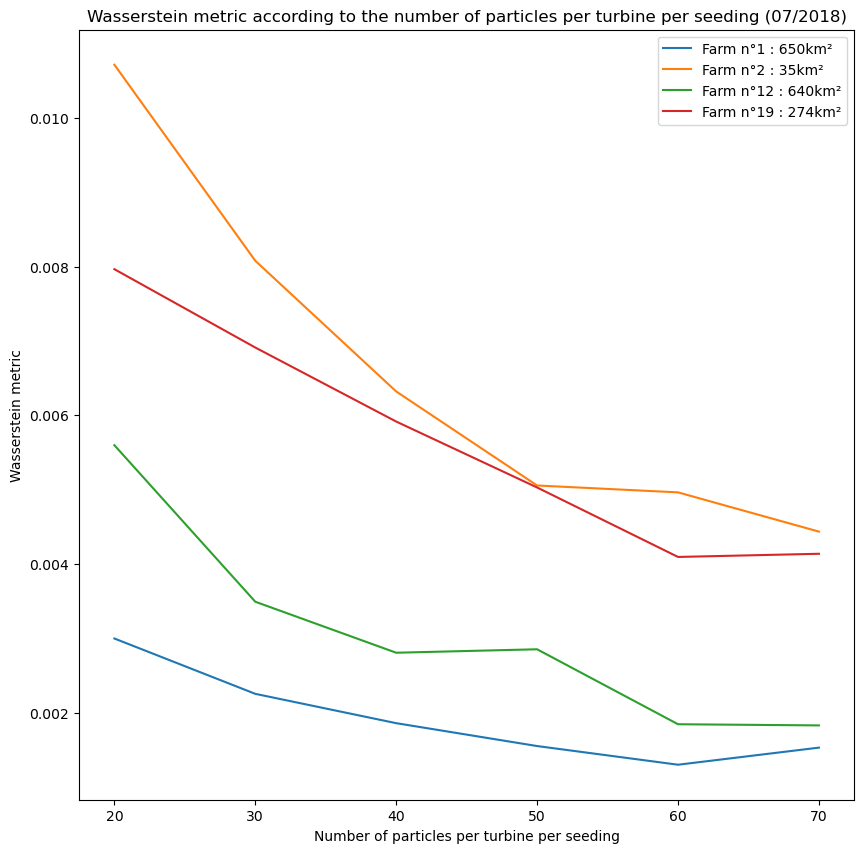

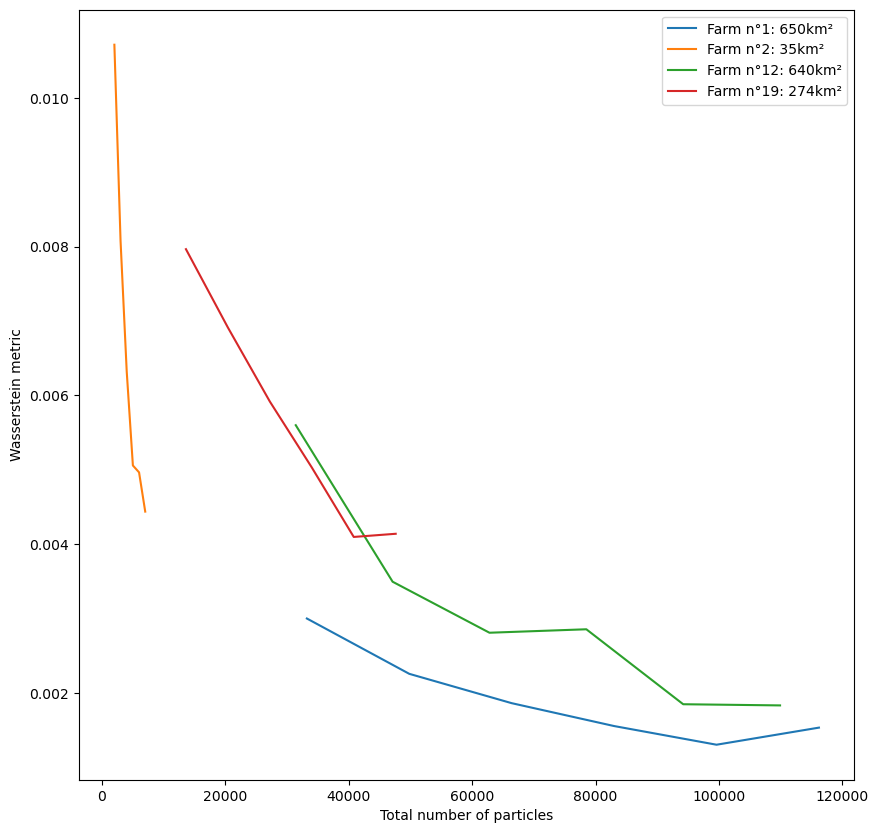

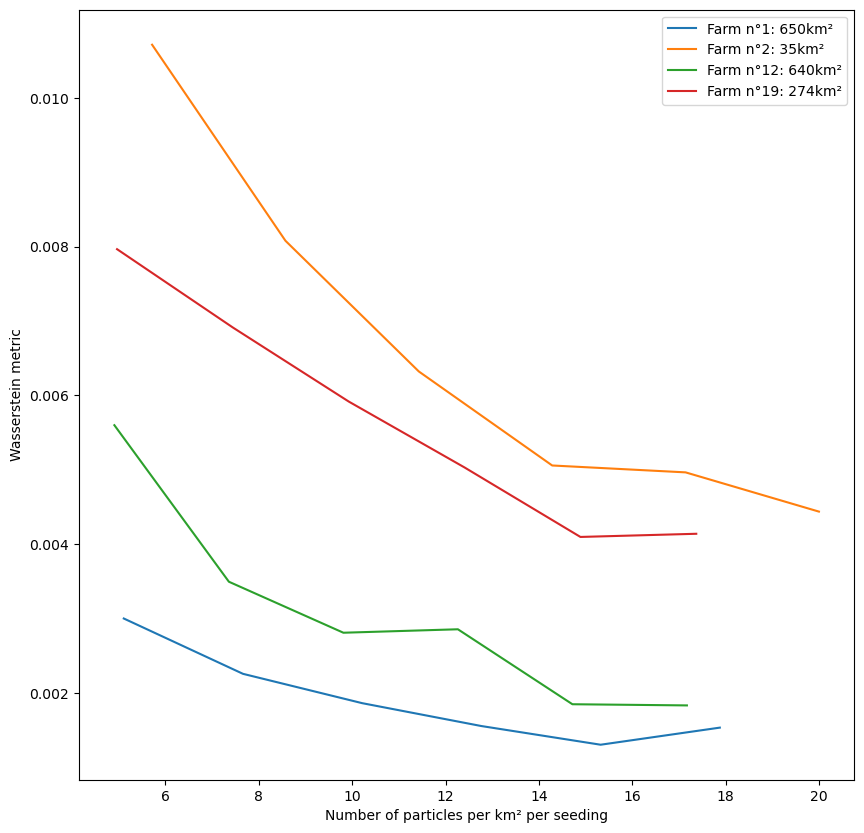

In [6]:
list2 = np.array([20, 30, 40, 50, 60, 70]) # number of particle per turbine per seeding
fig1, ax1 = plt.subplots(figsize=(10, 10))
fig2, ax2 = plt.subplots(figsize=(10, 10))
fig3, ax3 = plt.subplots(figsize=(10, 10))

for polygon in [1, 2, 12, 19]:
    d = np.zeros(len(list2))
    row = gdf.loc[gdf['FarmID'] == polygon]
    nb_t = row['N_turbines'].values[0]
    area = int(row['Area_km2'].values[0])
    for i, nb_p2 in enumerate(list2) :
        nb_p1 = list2[i] - 10
        
        file1 = 'sensibility_test_num_particle_{}_polygon_{}_{}_{}_uniqsum_raster.nc'.format(nb_p1,polygon,year,month_start)
        file2 = 'sensibility_test_num_particle_{}_polygon_{}_{}_{}_uniqsum_raster.nc'.format(nb_p2,polygon,year,month_start)
        ds1 = xr.open_dataset(infol + file1)
        ds2 = xr.open_dataset(infol + file2)
        d[i] = wasserstein_distance_nd(ds1.N_count, ds2.N_count)
         
        list_part_tot = list2.copy()*10*nb_t  # Number of particles used * number of seeding * number of turbines = total number
        list_part_area = list_part_tot.copy() / (area * 10) # Number of particles per km² per seeding
        
    ax1.plot(list2, d, label=f'Farm n°{polygon} : {area}km²')
    ax2.plot(list_part_tot, d, label=f'Farm n°{polygon}: {area}km²')
    ax3.plot(list_part_area, d, label=f'Farm n°{polygon}: {area}km²')

ax1.legend()
ax1.set_title(f'Wasserstein metric according to the number of particles per turbine per seeding (0{month_start}/{year})')
ax1.set_xlabel("Number of particles per turbine per seeding")
ax1.set_ylabel("Wasserstein metric")

ax2.legend()
ax2.set_title(f'Wasserstein metric according to the total number of particles (0{month_start}/{year})')
ax2.set_xlabel("Total number of particles")
ax2.set_ylabel("Wasserstein metric")

ax3.legend()
ax3.set_title(f'Wasserstein metric according to the number of particles per km² per seeding (0{month_start}/{year})')
ax3.set_xlabel("Number of particles per km² per seeding")
ax3.set_ylabel("Wasserstein metric")
plt.show()

fig1.savefig('sensibility_test_num_particle_turbine_{}_{}.png'.format(year,month_start))
fig2.savefig('sensibility_test_total_num_particle_{}_{}.png'.format(year,month_start))
fig3.savefig('sensibility_test_num_particle_area_{}_{}.png'.format(year,month_start))

### Comparison of 2 years : 2012 and 2018 ###

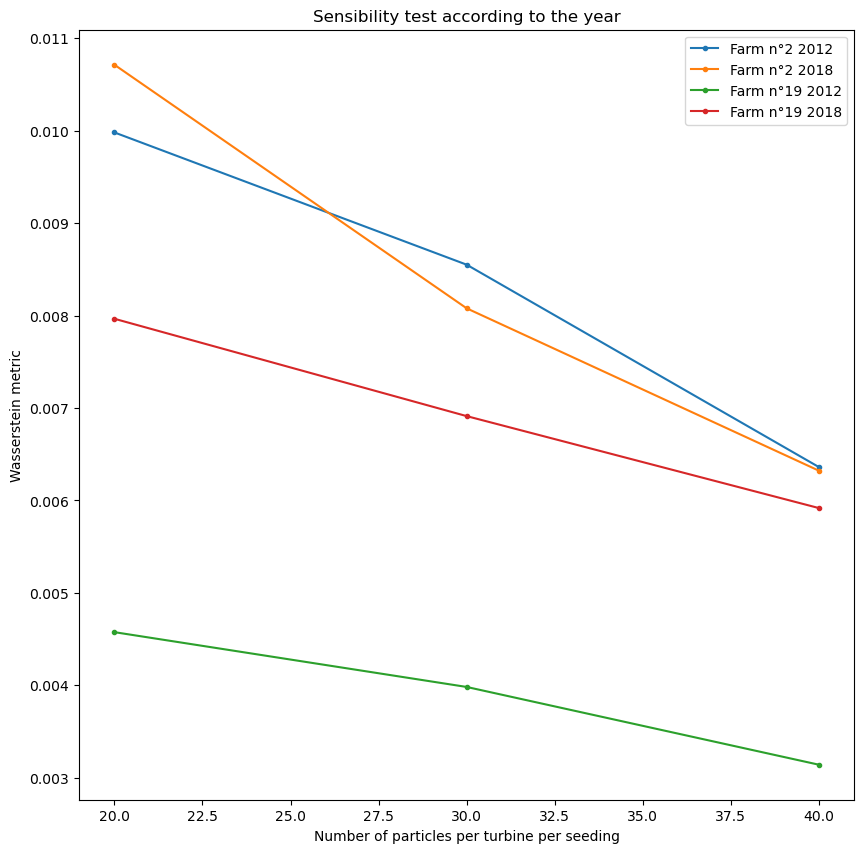

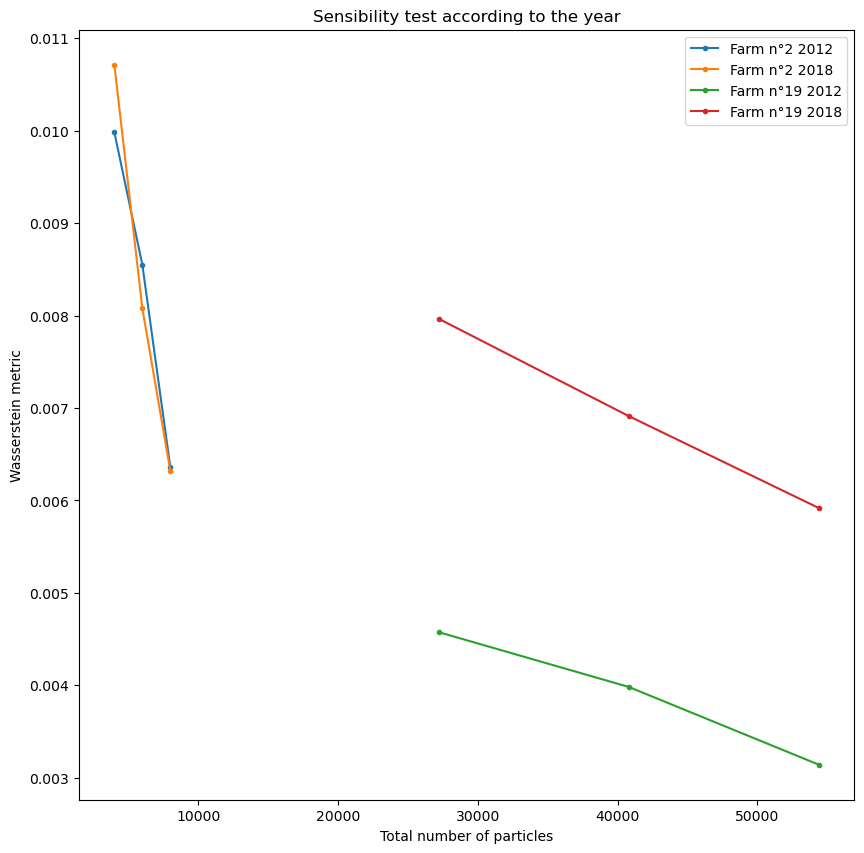

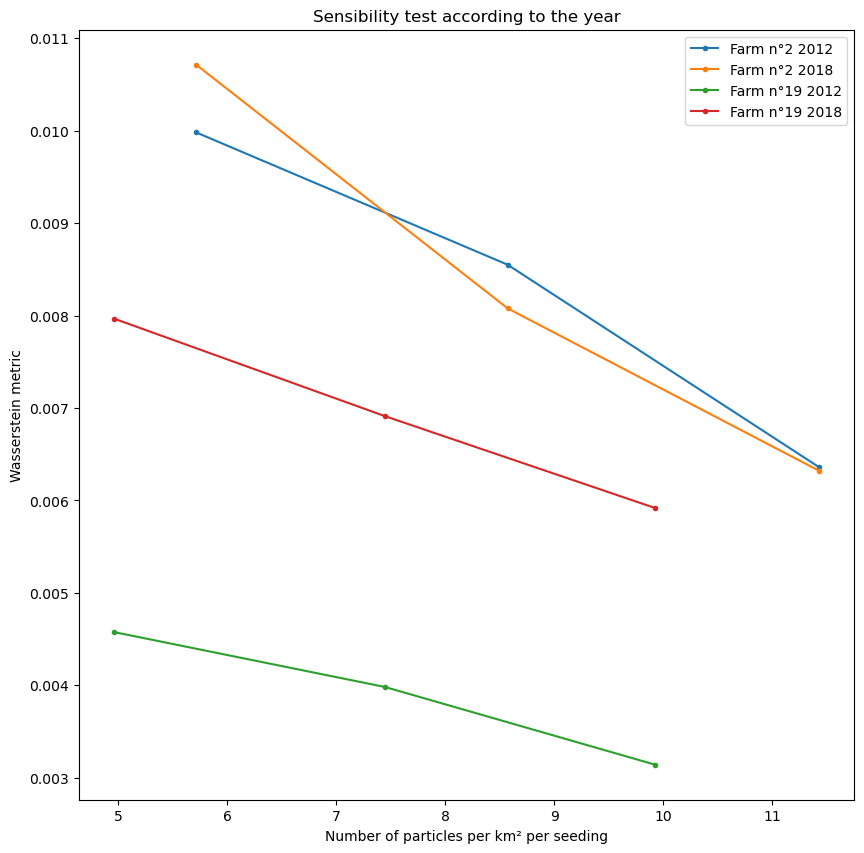

In [8]:
list2 = np.array([20, 30, 40]) # number of particle per turbine per seeding
fig1, ax1 = plt.subplots(figsize=(10, 10))
fig2, ax2 = plt.subplots(figsize=(10, 10))
fig3, ax3 = plt.subplots(figsize=(10, 10))

for polygon in [2, 19]:
    for year in [2012, 2018]:
        
        d = np.zeros(len(list2))
        row = gdf.loc[gdf['FarmID'] == polygon]
        nb_t = row['N_turbines'].values[0]
        area = int(row['Area_km2'].values[0])
        for i, nb_p2 in enumerate(list2) :
            nb_p1 = list2[i] - 10
            
            file1 = 'sensibility_test_num_particle_{}_polygon_{}_{}_{}_uniqsum_raster.nc'.format(nb_p1,polygon,year,month_start)
            file2 = 'sensibility_test_num_particle_{}_polygon_{}_{}_{}_uniqsum_raster.nc'.format(nb_p2,polygon,year,month_start)
            ds1 = xr.open_dataset(infol + file1)
            ds2 = xr.open_dataset(infol + file2)
            d[i] = wasserstein_distance_nd(ds1.N_count, ds2.N_count)
             
            list_part_tot = list2.copy()*20*nb_t  # Number of particles used * number of seeding * number of turbines = total number
            list_part_area = list_part_tot.copy() / (area * 20) # Number of particles per km² per seeding
            
        ax1.plot(list2, d, label=f'Farm n°{polygon} {year}', marker = '.')
        ax2.plot(list_part_tot, d, label=f'Farm n°{polygon} {year}', marker = '.')
        ax3.plot(list_part_area, d, label=f'Farm n°{polygon} {year}', marker = '.')

ax1.legend()
ax1.set_title(f'Sensibility test according to the year')
ax1.set_xlabel("Number of particles per turbine per seeding")
ax1.set_ylabel("Wasserstein metric")

ax2.legend()
ax2.set_title(f'Sensibility test according to the year')
ax2.set_xlabel("Total number of particles")
ax2.set_ylabel("Wasserstein metric")

ax3.legend()
ax3.set_title(f'Sensibility test according to the year')
ax3.set_xlabel("Number of particles per km² per seeding")
ax3.set_ylabel("Wasserstein metric")
plt.show()

fig1.savefig('sensibility_test_num_particle_turbine_year_comparison.png')
fig2.savefig('sensibility_test_total_num_particle_year_comparison.png')
fig3.savefig('sensibility_test_num_particle_area_year_comparison.png')

### Checking that the results don't change when using a grid in metres ###

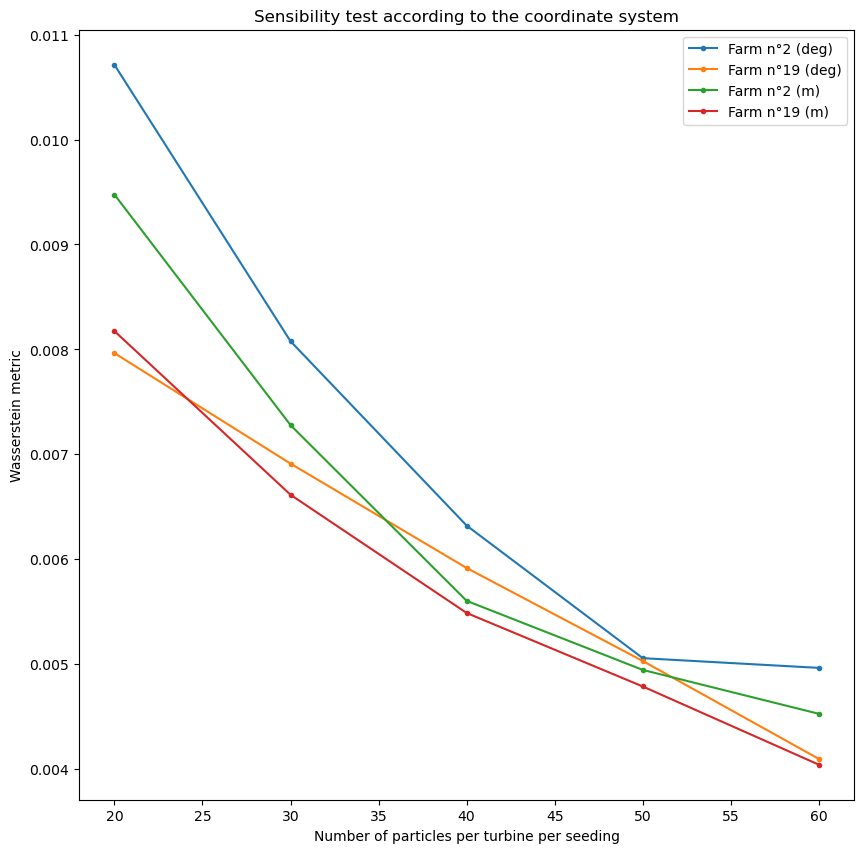

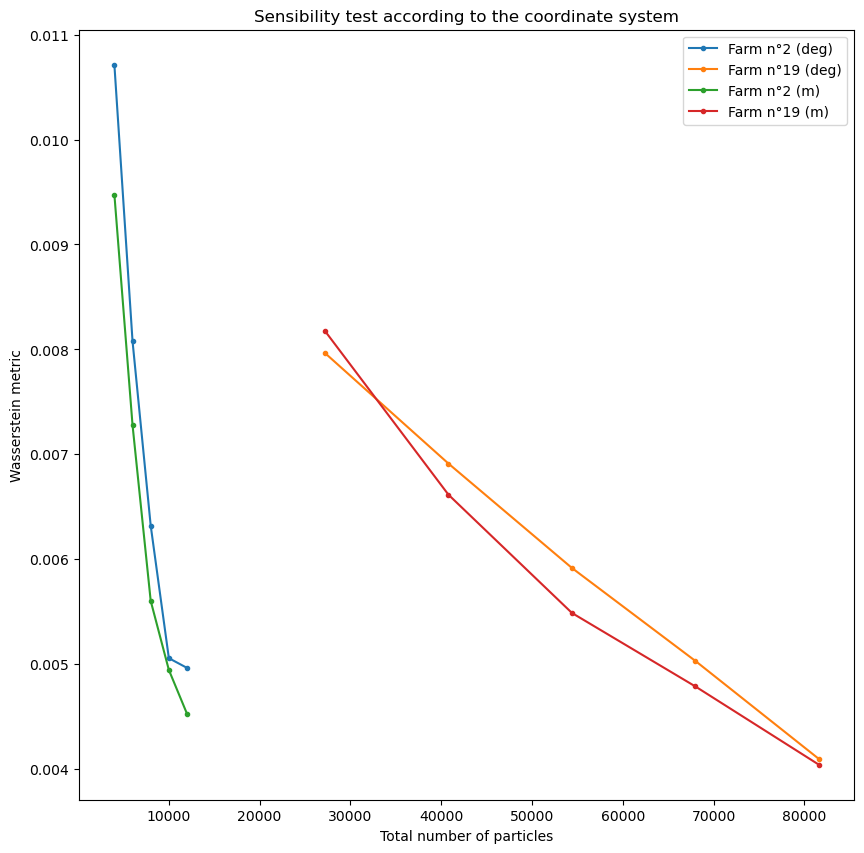

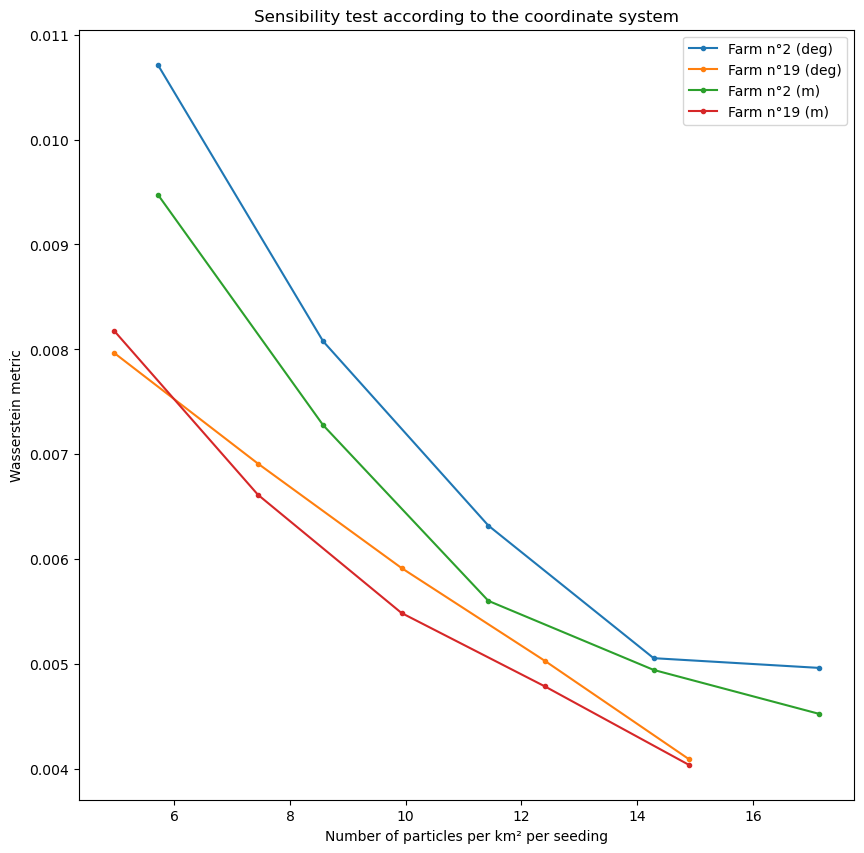

In [10]:
# Comparison between the degree and the metres grid
list2 = np.array([20, 30, 40, 50, 60]) # number of particle per turbine per seeding
fig1, ax1 = plt.subplots(figsize=(10, 10))
fig2, ax2 = plt.subplots(figsize=(10, 10))
fig3, ax3 = plt.subplots(figsize=(10, 10))

for coord in ['deg', 'm']:
    for polygon in [2, 19]:
        
        d = np.zeros(len(list2))
        row = gdf.loc[gdf['FarmID'] == polygon]
        nb_t = row['N_turbines'].values[0]
        area = int(row['Area_km2'].values[0])
        for i, nb_p2 in enumerate(list2) :
            nb_p1 = list2[i] - 10
            if coord == 'deg':
                file1 = 'sensibility_test_num_particle_{}_polygon_{}_{}_{}_uniqsum_raster.nc'.format(nb_p1,polygon,2018,month_start)
                file2 = 'sensibility_test_num_particle_{}_polygon_{}_{}_{}_uniqsum_raster.nc'.format(nb_p2,polygon,2018,month_start)
            else :
                file1 = 'sensibility_test_num_particle_{}_polygon_{}_{}_{}_uniqsum_raster_metres.nc'.format(nb_p1,polygon,2018,month_start)
                file2 = 'sensibility_test_num_particle_{}_polygon_{}_{}_{}_uniqsum_raster_metres.nc'.format(nb_p2,polygon,2018,month_start)
            ds1 = xr.open_dataset(infol + file1)
            ds2 = xr.open_dataset(infol + file2)
            d[i] = wasserstein_distance_nd(ds1.N_count, ds2.N_count)
             
            list_part_tot = list2.copy()*20*nb_t  # Number of particles used * number of seeding * number of turbines = total number
            list_part_area = list_part_tot.copy() / (area * 20) # Number of particles per km² per seeding
            
        ax1.plot(list2, d, label=f'Farm n°{polygon} ({coord})', marker = '.')
        ax2.plot(list_part_tot, d, label=f'Farm n°{polygon} ({coord})', marker = '.')
        ax3.plot(list_part_area, d, label=f'Farm n°{polygon} ({coord})', marker = '.')

ax1.legend()
ax1.set_title(f'Sensibility test according to the coordinate system')
ax1.set_xlabel("Number of particles per turbine per seeding")
ax1.set_ylabel("Wasserstein metric")

ax2.legend()
ax2.set_title(f'Sensibility test according to the coordinate system')
ax2.set_xlabel("Total number of particles")
ax2.set_ylabel("Wasserstein metric")

ax3.legend()
ax3.set_title(f'Sensibility test according to the coordinate system')
ax3.set_xlabel("Number of particles per km² per seeding")
ax3.set_ylabel("Wasserstein metric")
plt.show()

fig1.savefig('sensibility_test_num_particle_turbine_coord_comparison.png')
fig2.savefig('sensibility_test_total_num_particle_coord_comparison.png')
fig3.savefig('sensibility_test_num_particle_area_coord_comparison.png')